In [1]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper
from langchain_tavily import TavilySearch
from langchain_groq import ChatGroq

from langchain_core.messages import HumanMessage, SystemMessage
from langchain.tools import tool

import os
from dotenv import load_dotenv
load_dotenv()

c:\Users\sarth\Downloads\langrevison\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [38]:
arx = ArxivQueryRun(
    api_wrapper=ArxivAPIWrapper(top_k_results=3, doc_content_chars_max=500)
)

tav = TavilySearch(max_results=5)

tools = [tav, arx]

In [39]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.2,
    max_tokens=2000
)

llm_with_tools = llm.bind_tools(tools)

In [40]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]
    research: str
    draft: str
    final: str
    mode: str 
    

In [41]:
PLANNER_PROMPT = SystemMessage(content="""
You are a planning agent for a newsletter system.

Break the user goal into steps:
1. What to search (news + research)
2. What topics to focus on
3. What output structure is needed

Return a clear plan in bullet points.
""")

In [42]:
WRITER_PROMPT = SystemMessage(content="""
You are a professional AI newsletter writer.

Create a structured Markdown newsletter:

 Top AI Agent News (5-7 items)
 Research Papers Summary
 AI Tools & Frameworks
 Key Insights
 Weekly Summary

Make it clean, factual, and readable.
""")

In [43]:
CRITIC_PROMPT = SystemMessage(content="""
You are a strict editor.

Check:
- factual accuracy
- clarity
- structure
- missing important news

Improve the newsletter if needed.

Return FINAL improved newsletter only.
""")

In [44]:
def planner(state: State):
    goal = state["messages"][-1].content

    plan = llm.invoke([
        PLANNER_PROMPT,
        HumanMessage(content=goal)
    ])

    return {
        "messages": [plan]
    }

In [45]:
def research(state: State):
    query = state["messages"][0].content

    news = tav.invoke(query)
    papers = arx.invoke("AI agents latest research")

    combined = f"""
NEWS:
{news}

PAPERS:
{papers}
"""

    return {
        "research": combined,
        "messages": [HumanMessage(content=combined)]
    }

In [46]:
def writer(state: State):
    research = state["research"]

    draft = llm.invoke([
        WRITER_PROMPT,
        HumanMessage(content=research)
    ])

    return {
        "draft": draft.content,
        "messages": [draft]
    }

In [47]:
def critic(state: State):
    draft = state["draft"]

    final = llm.invoke([
        CRITIC_PROMPT,
        HumanMessage(content=draft)
    ])

    return {
        "final": final.content,
        "messages": [final]
    }

In [48]:
def output(state: State):
    content = state["final"]

    with open("newsletter.md", "w", encoding="utf-8") as f:
        f.write(content)

    print("\n========== NEWSLETTER ==========\n")
    print(content)

    return state

In [49]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("planner", planner)
builder.add_node("research", research)
builder.add_node("writer", writer)
builder.add_node("critic", critic)
builder.add_node("output", output)

In [50]:
builder.add_edge(START, "planner")
builder.add_edge("planner", "research")
builder.add_edge("research", "writer")
builder.add_edge("writer", "critic")
builder.add_edge("critic", "output")
builder.add_edge("output", END)

In [51]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

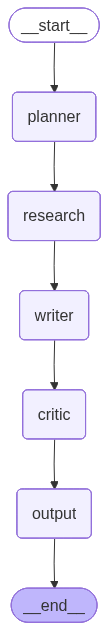

In [52]:
graph

In [53]:
def run_newsletter_agent(goal: str, mode="autonomous"):

    result = graph.invoke(
        {
            "messages": [HumanMessage(content=goal)],
            "mode": mode
        },
        config={
            "configurable": {
                "thread_id": "newsletter-run-1"
            }
        }
    )

    return result["final"]

In [54]:
goal = "Create a weekly newsletter on latest AI agent news and research papers"

output = run_newsletter_agent(goal)
print(output)


========== NEWSLETTER ==========

### 🔥 Top AI Agent News
1. **TaskifyLabs AI Agent Newsletter Review**: A list of the top 10 AI agent newsletters in 2026, featuring newsletters that cover agents and their applications, including their frequency, content, and target audience.
2. **AI-Powered Newsletter Agent**: A Reddit user developed a simple AI-powered newsletter agent that researches topics and generates well-structured newsletters, utilizing natural language processing (NLP) and machine learning algorithms.
3. **AI Weekly Newsletter**: A weekly newsletter that delivers curated AI updates on funding, models, regulation, and applications to over 44,000 professionals, providing insights into the latest industry trends and breakthroughs.
4. **AI Agent for Tech News Curation**: A comprehensive guide on how to build an AI agent to curate tech news and newsletters, including responding to emails and booking dinners, using tools such as Kaggle and TaskifyLabs.
5. **Top AI Newsletters on K